### Non-Parametric Model Options

In [1]:
# installing dependencies / library

!pip install pybaseball

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 426.1/426.1 kB 6.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 432.7/432.7 kB 13.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 21.7 MB/s eta 0:00:00


In [2]:
# importing libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
import random
import networkx as nx

from pybaseball import statcast
from scipy.stats import gaussian_kde
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
from sklearn.cluster import KMeans
from sklearn.neighbors import KernelDensity


In [3]:
# Example: October 2025 data

data = statcast(start_dt='2025-10-01', end_dt='2025-10-07')

data.head()

This is a large query, it may take a moment to complete


  0%|          | 0/7 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/pybaseball/datahelpers/postprocessing.py:59: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_datetime without passing `errors` and catch exceptions explicitly instead
  data_copy[column] = data_copy[column].apply(pd.to_datetime, errors='ignore', format=date_format)
/usr/local/lib/python3.12/dist-packages/pybaseball/datahelpers/postprocessing.py:59: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_datetime without passing `errors` and catch exceptions explicitly instead
  data_copy[column] = data_copy[column].apply(pd.to_datetime, errors='ignore', format=date_format)
/usr/local/lib/python3.12/dist-packages/pybaseball/datahelpers/postprocessing.py:59: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_datetime without passing `errors` and catch exceptions explicitly instead
  data_copy[column] = da

,pitch_type,game_date,release_speed,release_pos_x,release_pos_z,player_name,batter,pitcher,events,description,...,batter_days_until_next_game,api_break_z_with_gravity,api_break_x_arm,api_break_x_batter_in,arm_angle,attack_angle,attack_direction,swing_path_tilt,intercept_ball_minus_batter_pos_x_inches,intercept_ball_minus_batter_pos_y_inches
214,FF,2025-10-07,98.3,-1.54,6.02,"Bednar, David",665489,670280,field_out,hit_into_play,...,1,0.97,0.84,0.84,45.0,5.870909,-11.890249,25.365388,40.642474,37.568685
227,FF,2025-10-07,98.0,-1.62,6.06,"Bednar, David",665489,670280,NaN,foul,...,1,0.89,0.71,0.71,39.1,-0.996442,0.243093,30.472424,24.964442,29.359089
238,FF,2025-10-07,97.9,-1.53,6.01,"Bednar, David",665489,670280,NaN,foul_tip,...,1,0.75,0.43,0.43,40.3,-3.712189,-0.50298,23.12678,42.875017,29.004779
241,FF,2025-10-07,98.2,-1.74,5.9,"Bednar, David",665489,670280,NaN,called_strike,...,1,0.81,0.61,0.61,35.8,<NA>,<NA>,<NA>,<NA>,<NA>
261,CU,2025-10-07,77.5,-1.87,6.01,"Bednar, David",665489,670280,NaN,ball,...,1,4.19,-0.66,-0.66,36.9,<NA>,<NA>,<NA>,<NA>,<NA>


1. Empirical Cumulative Distribution Functions (ECDF) :

  - Use case:
    - Inferential modeling of distributions (e.g. release speed, launch angle, exit velocity, etc.)

  - Fitting:
    - Compute ECDFs for key variables to understand their distribution without assuming parametric forms.

  - Realism:
    - Captures the true distribution shape, including skewness and multimodality.

  - Bootstrap:
    - Sample values from ECDF to estimate confidence intervals or simulate realistic distributions.

Descriptive: ECDF, KDE

In [4]:
# data subset

pitch_speeds = data['release_speed'].dropna()

pitch_speeds

,release_speed
214,98.3
227,98.0
238,97.9
241,98.2
261,77.5
...,...
998,95.4
1043,94.3
1086,94.9
1140,89.9


<Axes: xlabel='release_speed', ylabel='Count'>

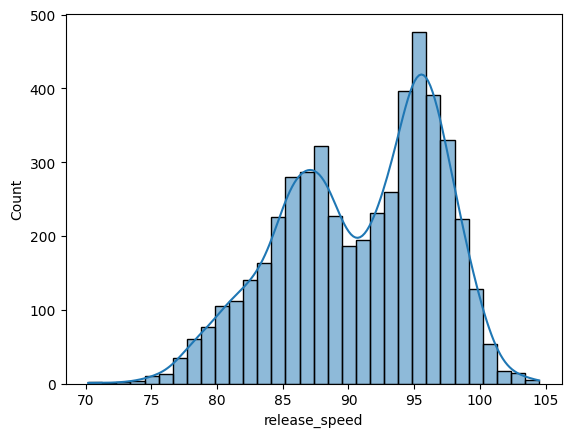

In [5]:
sns.histplot(pitch_speeds, kde=True)

In [6]:
data.groupby("pitch_type").release_speed.agg("mean").sort_values()

,release_speed
pitch_type,
CU,80.453691
ST,83.402679
SV,84.271429
KC,84.54918
CH,86.714191
FS,86.866769
SL,87.211181
FC,90.985944
SI,95.27293


In [7]:
data.groupby("pitch_type").release_speed.agg("count").sort_values()

,release_speed
pitch_type,
SV,35
KC,122
ST,224
FC,249
CU,298
FS,325
CH,451
SI,761
SL,796


In [8]:
# define ecdf function

def ecdf(data):
    x = np.sort(data)
    y = np.arange(1, len(x)+1) / len(x)
    return x, y


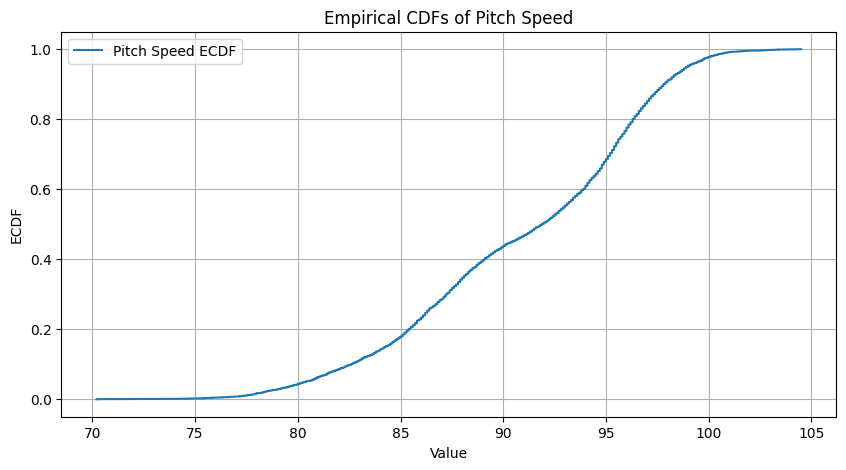

In [9]:
x_ev, y_ev = ecdf(pitch_speeds)

# Plot
plt.figure(figsize=(10, 5))
plt.plot(x_ev, y_ev, label='Pitch Speed ECDF')
plt.xlabel('Value')
plt.ylabel('ECDF')
plt.legend()
plt.title('Empirical CDFs of Pitch Speed')

plt.grid(True)
plt.show()

Inferential: Bootstrap CI

In [10]:
# Bootstrap Sampling from ECDF
# To simulate realistic distributions or estimate confidence intervals:

bootstrap_medians = [np.median(np.random.choice(pitch_speeds, size=1000, replace=True)) for _ in range(1000)]

ci_90 = np.percentile(bootstrap_medians, [5, 95])


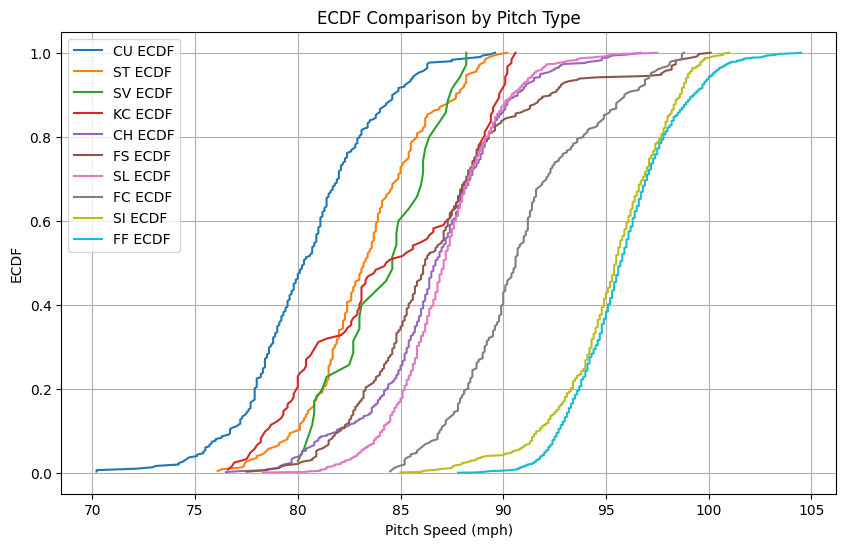

In [11]:
# Select pitch types to compare
pitch_types = ['CU','ST','SV','KC','CH','FS','SL','FC','SI','FF']

# CU: Curveball
# ST: Sweeper
# SV: Slurve
# KC: Knuckle-curve
# CH: Changeup
# FS: Splitter (or Split-fingered fastball)
# SL: Slider
# FC: Cutter (or Fastball-cutter)
# SI: Sinker
# FF: Four-Seam Fastball


plt.figure(figsize=(10, 6))
for pt in pitch_types:
    speeds = data[data['pitch_type'] == pt]['release_speed']
    x, y = ecdf(speeds)
    plt.plot(x, y, label=f'{pt} ECDF')

plt.xlabel('Pitch Speed (mph)')
plt.ylabel('ECDF')
plt.title('ECDF Comparison by Pitch Type')
plt.legend()
plt.grid(True)
plt.show()

In [12]:
# Example: 90th percentile for fastballs

fastball_speeds = data[data['pitch_type'] == 'FF']['release_speed']
percentile_90 = np.percentile(fastball_speeds, 90)

print(f"90th percentile pitch speed for fastballs: {percentile_90:.2f} mph")


90th percentile pitch speed for fastballs: 99.30 mph


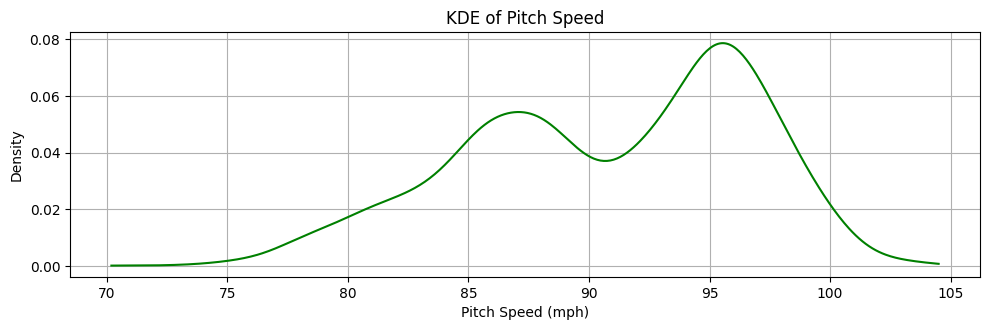

In [13]:
# Step 3: Compute KDE
kde = gaussian_kde(pitch_speeds)
x_kde = np.linspace(min(pitch_speeds), max(pitch_speeds), 500)
y_kde = kde(x_kde)


# KDE
plt.figure(figsize=(10, 6))
plt.subplot(2, 1, 2)
plt.plot(x_kde, y_kde, color='green')
plt.title('KDE of Pitch Speed')
plt.xlabel('Pitch Speed (mph)')
plt.ylabel('Density')
plt.grid(True)

plt.tight_layout()
plt.show()

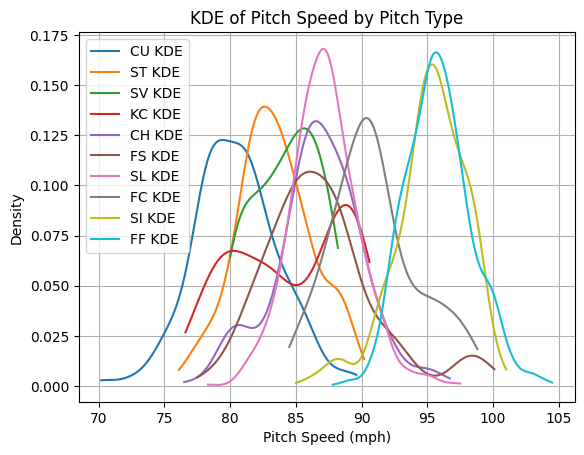

In [14]:
for pt in pitch_types:
    speeds = data[data['pitch_type'] == pt]['release_speed']
    if len(speeds) > 0:
        kde = gaussian_kde(speeds)
        x_vals = np.linspace(min(speeds), max(speeds), 500)
        y_vals = kde(x_vals)
        plt.plot(x_vals, y_vals, label=f'{pt} KDE')

plt.xlabel('Pitch Speed (mph)')
plt.ylabel('Density')
plt.title('KDE of Pitch Speed by Pitch Type')
plt.legend()
plt.grid(True)
plt.show()

In [15]:
n_boot = 1000

# Step 3: Bootstrap for each pitch type
results = {}

for pt in pitch_types:
    speeds = data[data['pitch_type'] == pt]['release_speed'].values
    if len(speeds) > 0:
        boot_medians = [np.median(np.random.choice(speeds, size=len(speeds), replace=True)) for _ in range(n_boot)]
        boot_p90s = [np.percentile(np.random.choice(speeds, size=len(speeds), replace=True), 90) for _ in range(n_boot)]
        ci_median = np.percentile(boot_medians, [2.5, 97.5])
        ci_p90 = np.percentile(boot_p90s, [2.5, 97.5])
        results[pt] = {
            'median_CI': ci_median,
            'p90_CI': ci_p90
        }

# Step 4: Display results
for pt, stats in results.items():
    print(f"{pt} - Median CI: {stats['median_CI'][0]:.2f} to {stats['median_CI'][1]:.2f} mph")
    print(f"{pt} - 90th Percentile CI: {stats['p90_CI'][0]:.2f} to {stats['p90_CI'][1]:.2f} mph\n")

CU - Median CI: 79.80 to 80.90 mph
CU - 90th Percentile CI: 84.00 to 85.40 mph

ST - Median CI: 82.70 to 83.70 mph
ST - 90th Percentile CI: 86.51 to 88.20 mph

SV - Median CI: 83.00 to 85.80 mph
SV - 90th Percentile CI: 86.16 to 88.20 mph

KC - Median CI: 83.10 to 86.91 mph
KC - 90th Percentile CI: 89.39 to 90.10 mph

CH - Median CI: 86.40 to 87.20 mph
CH - 90th Percentile CI: 90.10 to 91.10 mph

FS - Median CI: 85.80 to 87.10 mph
FS - 90th Percentile CI: 91.12 to 93.12 mph

SL - Median CI: 86.90 to 87.30 mph
SL - 90th Percentile CI: 90.10 to 90.90 mph

FC - Median CI: 90.10 to 91.00 mph
FC - 90th Percentile CI: 95.20 to 96.90 mph

SI - Median CI: 95.30 to 95.60 mph
SI - 90th Percentile CI: 98.30 to 98.80 mph

FF - Median CI: 95.60 to 95.90 mph
FF - 90th Percentile CI: 99.00 to 99.60 mph



What you will learn :
- How pitch speed varies within each pitch type.

- Which pitch types have tighter or wider velocity ranges.

- Whether fastballs, sliders, or changeups have more stable velocity profiles.

Comparative: Stratified by pitch type, pitcher, and count

Stratify by the pitcher

In [16]:
# Step 1: Choose pitchers to analyze
pitchers = data['pitcher'].value_counts().head(3).index.tolist()  # Top 3 pitchers by pitch count

pitchers

[607074, 656427, 684007]

In [17]:
# Step 2: Bootstrap for each pitcher
for pid in pitchers:

    speeds = data[data['pitcher'] == pid]['release_speed'].dropna().values

    boot_medians = [np.median(np.random.choice(speeds, size=len(speeds), replace=True)) for _ in range(n_boot)]
    boot_p90s = [np.percentile(np.random.choice(speeds, size=len(speeds), replace=True), 90) for _ in range(n_boot)]

    ci_median = np.percentile(boot_medians, [2.5, 97.5])
    ci_p90 = np.percentile(boot_p90s, [2.5, 97.5])

    print(f"Pitcher {pid} - Median CI: {ci_median[0]:.2f} to {ci_median[1]:.2f} mph")
    print(f"Pitcher {pid} - 90th Percentile CI: {ci_p90[0]:.2f} to {ci_p90[1]:.2f} mph\n")


Pitcher 607074 - Median CI: 87.70 to 92.90 mph
Pitcher 607074 - 90th Percentile CI: 94.50 to 95.20 mph

Pitcher 656427 - Median CI: 86.75 to 88.10 mph
Pitcher 656427 - 90th Percentile CI: 94.20 to 95.31 mph

Pitcher 684007 - Median CI: 90.70 to 91.60 mph
Pitcher 684007 - 90th Percentile CI: 92.40 to 92.90 mph



Pitch Speed by Pitch Type Across Pitchers

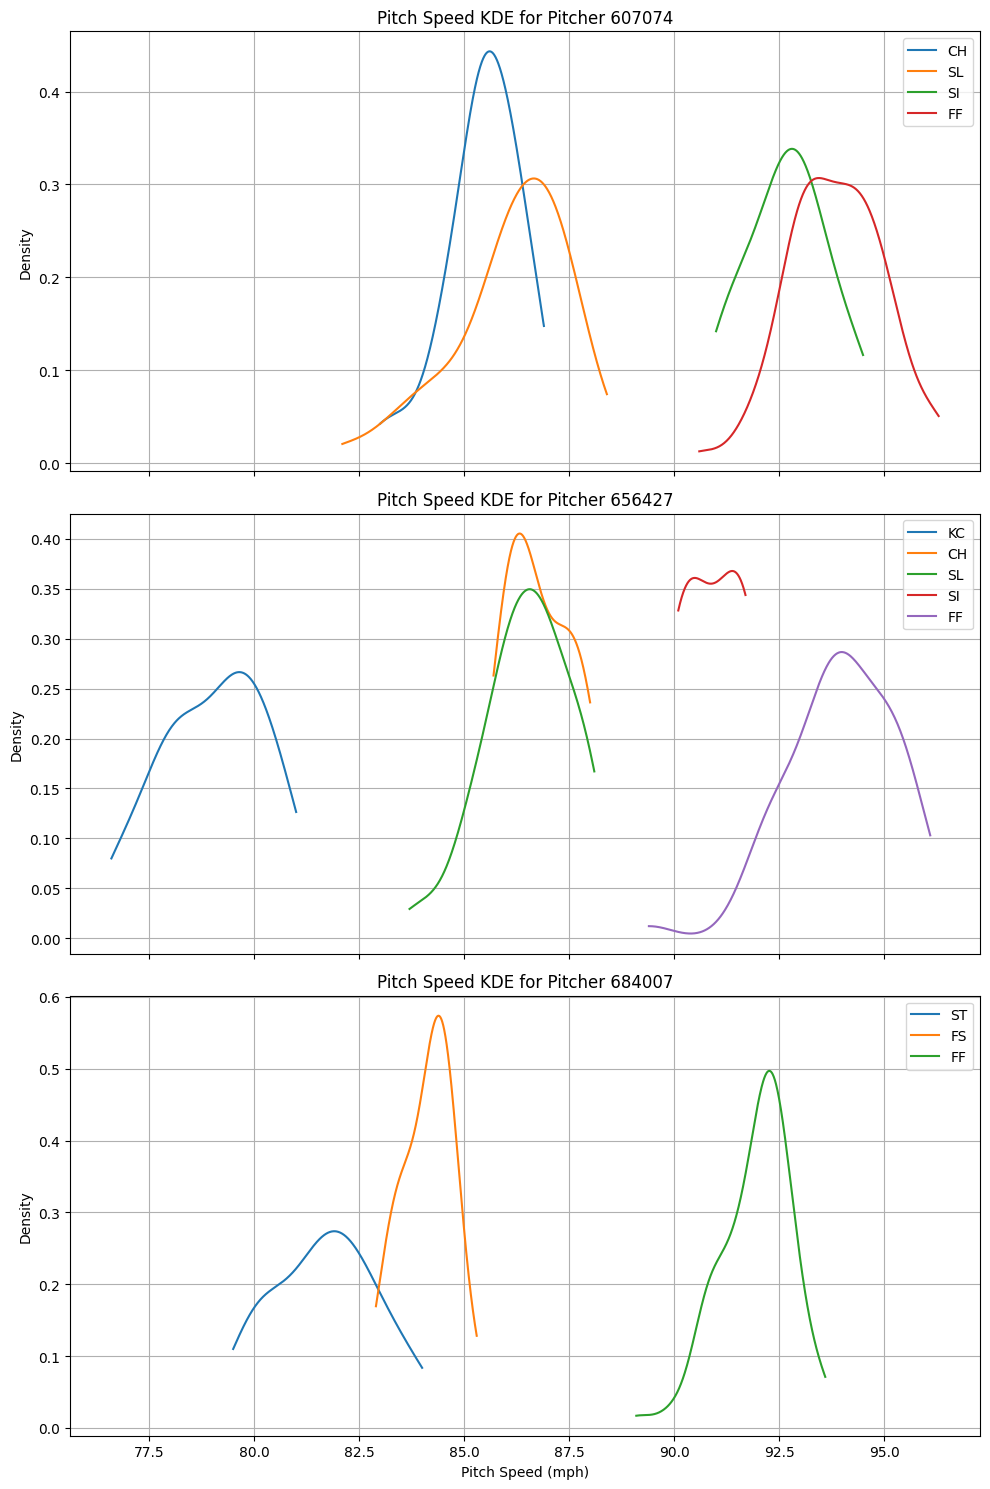

In [18]:
# Get top 3 pitchers by pitch count
top_pitchers = data['pitcher'].value_counts().head(3).index.tolist()

# Plot setup
fig, axes = plt.subplots(len(top_pitchers), 1, figsize=(10, 5 * len(top_pitchers)), sharex=True)

for i, pid in enumerate(top_pitchers):
    ax = axes[i]
    pitcher_df = data[data['pitcher'] == pid]
    for pt in pitch_types:
        speeds = pitcher_df[pitcher_df['pitch_type'] == pt]['release_speed']
        if len(speeds) > 1:
            kde = gaussian_kde(speeds)
            x_vals = np.linspace(min(speeds), max(speeds), 500)
            y_vals = kde(x_vals)
            ax.plot(x_vals, y_vals, label=pt)
    ax.set_title(f'Pitch Speed KDE for Pitcher {pid}')
    ax.set_ylabel('Density')
    ax.legend()
    ax.grid(True)

plt.xlabel('Pitch Speed (mph)')
plt.tight_layout()
plt.show()

Pitch Type Usage Across Counts

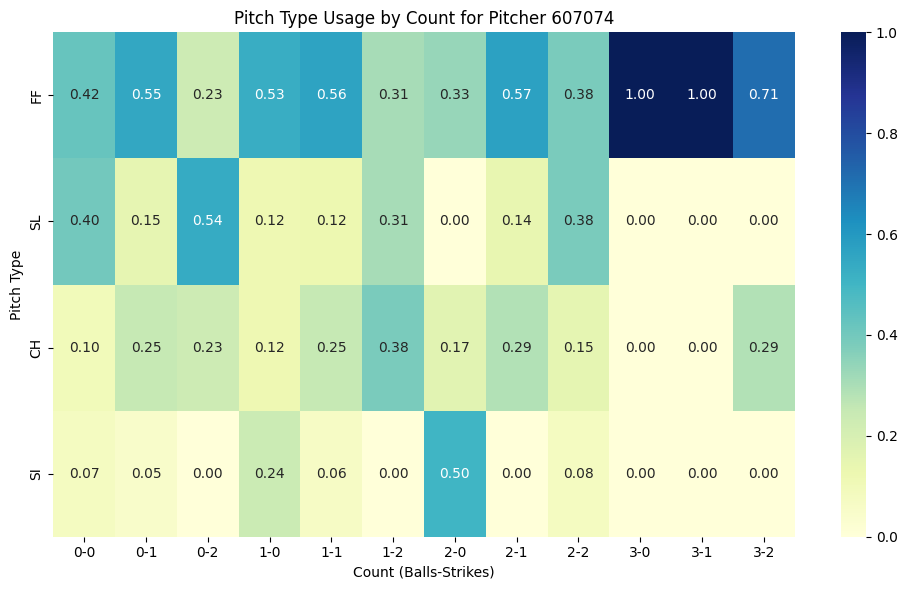

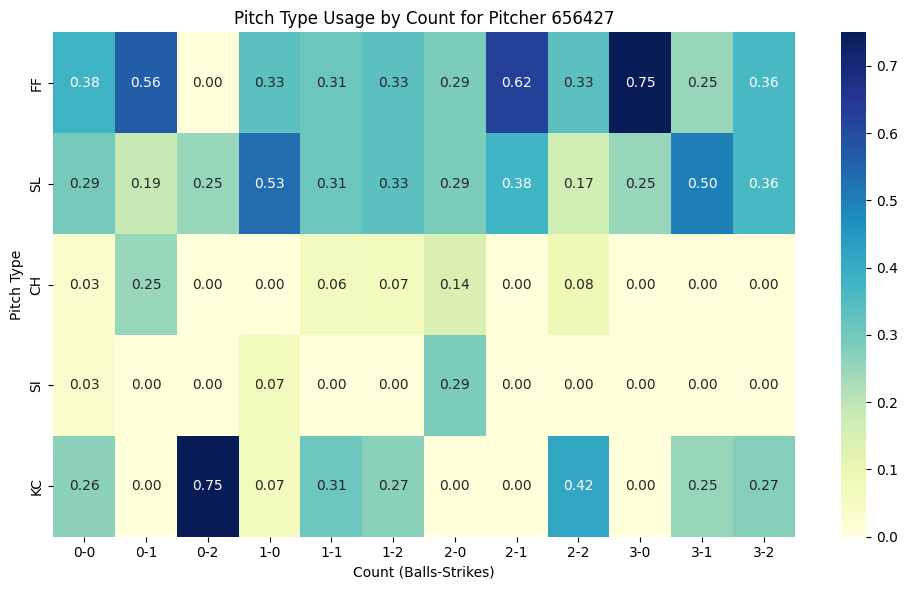

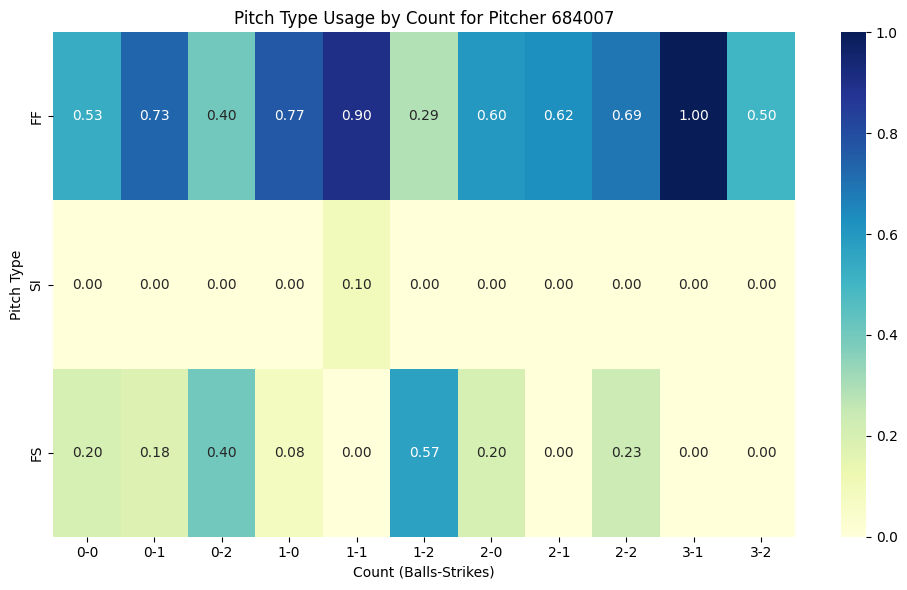

In [19]:
df = data[['pitcher', 'pitch_type', 'balls', 'strikes']].dropna()

# Define consistent pitch type order
pitch_order = ['FF', 'SL', 'CH', 'CU', 'SI', 'FC', 'FS', 'KC', 'KN', 'EP']  # Add/remove as needed

# Step 2: Create count label
df['count'] = df['balls'].astype(str) + '-' + df['strikes'].astype(str)

# Step 3: Get top 3 pitchers by pitch volume
top_pitchers = df['pitcher'].value_counts().head(3).index.tolist()

# Step 4: Plot heatmap for each pitcher
for pid in top_pitchers:
    sub_df = df[df['pitcher'] == pid]

    count_matrix = pd.crosstab(sub_df['pitch_type'], sub_df['count'])
    count_matrix = count_matrix.div(count_matrix.sum(axis=0), axis=1)  # Normalize by column (count)
    count_matrix = count_matrix.reindex(pitch_order).dropna(how='all')  # Reorder and drop unused rows

    plt.figure(figsize=(10, 6))
    sns.heatmap(count_matrix, annot=True, fmt=".2f", cmap="YlGnBu")
    plt.title(f'Pitch Type Usage by Count for Pitcher {pid}')
    plt.xlabel('Count (Balls-Strikes)')
    plt.ylabel('Pitch Type')
    plt.tight_layout()
    plt.show()

Goal : Predict pitch type based on count, pitcher, and other features.

In [20]:
# Create count label
data['count'] = data['balls'].astype(str) + '-' + data['strikes'].astype(str)

# Encode categorical variables
data['pitch_type'] = data['pitch_type'].astype('category')
data['pitcher'] = data['pitcher'].astype('category')
data['count'] = data['count'].astype('category')

X = pd.get_dummies(data[['pitcher', 'count']], drop_first=True)
y = data['pitch_type'].cat.codes

# Train model
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y)
model = RandomForestClassifier()
model.fit(X_train, y_train)

# Evaluate
y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred, target_names=data['pitch_type'].cat.categories))

              precision    recall  f1-score   support

          CH       0.42      0.27      0.33       113
          CU       0.33      0.27      0.30        75
          FC       0.31      0.29      0.30        62
          FF       0.46      0.56      0.51       428
          FS       0.59      0.44      0.51        81
          KC       0.41      0.29      0.34        31
          SI       0.46      0.48      0.47       190
          SL       0.38      0.37      0.38       199
          ST       0.39      0.34      0.36        56
          SV       0.60      0.33      0.43         9

    accuracy                           0.44      1244
   macro avg       0.44      0.37      0.39      1244
weighted avg       0.43      0.44      0.43      1244



Goal: Generate synthetic pitch sequences based on learned probabilities.

In [21]:
# Get pitch type probabilities for a pitcher at a count
def simulate_pitch(pitcher_id, count_label):

    input_df = pd.get_dummies(pd.DataFrame({'pitcher': [pitcher_id], 'count': [count_label]}))

    input_df = input_df.reindex(columns=X.columns, fill_value=0)

    probs = model.predict_proba(input_df)[0]

    pitch_type = np.random.choice(data['pitch_type'].cat.categories, p=probs)

    return pitch_type

# Simulate a sequence
sequence = []
for count in ['0-0', '1-0', '1-1', '2-2', '3-2']:
    pitch = simulate_pitch(pitcher_id=top_pitchers[0], count_label=count)
    sequence.append((count, pitch))

print("Simulated pitch sequence:")
for count, pitch in sequence:
    print(f"Count {count} → Pitch: {pitch}")


Simulated pitch sequence:
Count 0-0 → Pitch: SL
Count 1-0 → Pitch: SL
Count 1-1 → Pitch: FS
Count 2-2 → Pitch: FF
Count 3-2 → Pitch: FF


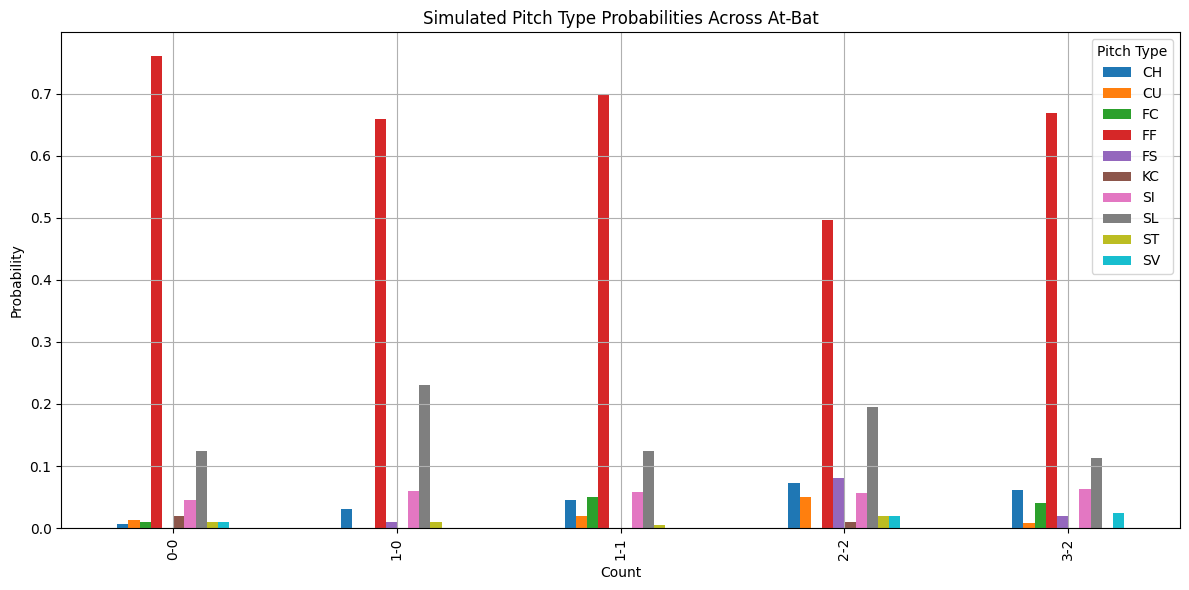

In [25]:

X = pd.get_dummies(df[['pitcher', 'batter', 'stand', 'count']], drop_first=True)
y = data['pitch_type'].cat.codes
pitch_labels = df['pitch_type'].cat.categories

# Simulate pitch type probabilities across counts
pitcher_id = data['pitcher'].value_counts().index[0]
batter_id = data['batter'].value_counts().index[0]
stand = 'R'
counts = ['0-0', '1-0', '1-1', '2-2', '3-2']

prob_matrix = []

for count in counts:
    input_df = pd.DataFrame({'pitcher': [pitcher_id], 'batter': [batter_id], 'stand': [stand], 'count': [count]})
    input_df = pd.get_dummies(input_df)
    input_df = input_df.reindex(columns=X.columns, fill_value=0)
    probs = model.predict_proba(input_df)[0]
    prob_matrix.append(probs)

# Convert to DataFrame for plotting
prob_df = pd.DataFrame(prob_matrix, columns=pitch_labels, index=counts)

# Plot grouped bar chart
prob_df.plot(kind='bar', figsize=(12, 6))
plt.title('Simulated Pitch Type Probabilities Across At-Bat')
plt.xlabel('Count')
plt.ylabel('Probability')
plt.legend(title='Pitch Type')
plt.grid(True)
plt.tight_layout()
plt.show()


Goal: Add batter handedness or ID to improve predictions.

In [26]:
df = data[['pitch_type', 'pitcher', 'batter', 'stand', 'balls', 'strikes']].dropna()

df['count'] = df['balls'].astype(str) + '-' + df['strikes'].astype(str)

# Encode batter and handedness
df['pitch_type'] = df['pitch_type'].astype('category')
df['pitcher'] = df['pitcher'].astype('category')
df['batter'] = df['batter'].astype('category')
df['stand'] = df['stand'].astype('category')
df['count'] = df['count'].astype('category')

X = pd.get_dummies(df[['pitcher', 'batter', 'stand', 'count']], drop_first=True)
y = df['pitch_type'].cat.codes

X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y)
model = RandomForestClassifier()
model.fit(X_train, y_train)

print("Updated model with batter context:")
print(classification_report(y_test, model.predict(X_test), target_names=df['pitch_type'].cat.categories))


Updated model with batter context:
              precision    recall  f1-score   support

          CH       0.40      0.34      0.37       113
          CU       0.35      0.24      0.28        75
          FC       0.37      0.31      0.34        62
          FF       0.49      0.54      0.51       428
          FS       0.39      0.31      0.34        81
          KC       0.41      0.29      0.34        31
          SI       0.41      0.49      0.45       190
          SL       0.43      0.45      0.44       199
          ST       0.19      0.16      0.17        56
          SV       0.38      0.56      0.45         9

    accuracy                           0.43      1244
   macro avg       0.38      0.37      0.37      1244
weighted avg       0.42      0.43      0.42      1244



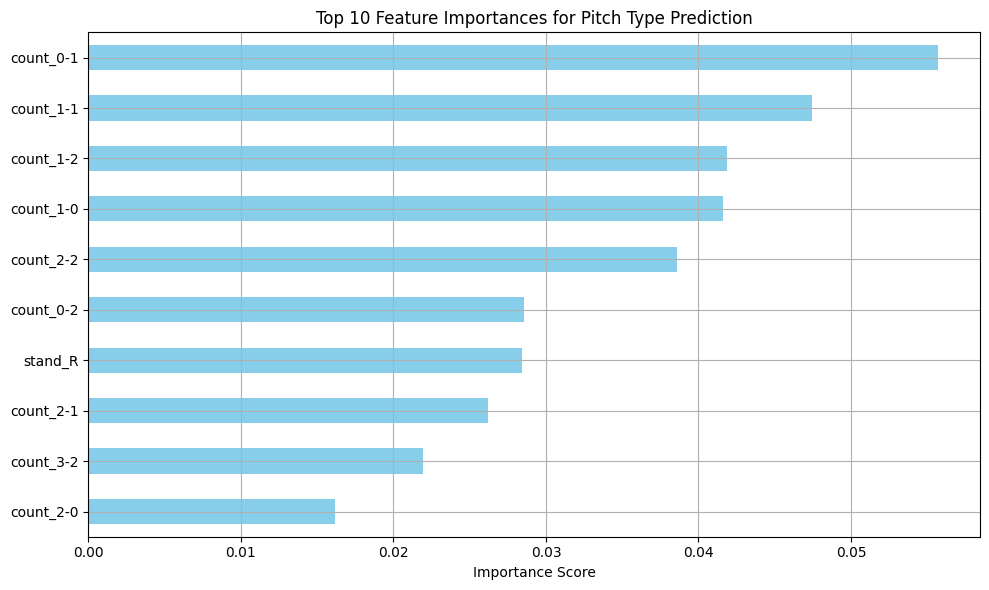

In [24]:
# Train model
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y)
model = RandomForestClassifier()
model.fit(X_train, y_train)

# Feature importance
importances = pd.Series(model.feature_importances_, index=X.columns)
top_features = importances.sort_values(ascending=False).head(10)

# Plot
plt.figure(figsize=(10, 6))
top_features.plot(kind='barh', color='skyblue')
plt.title('Top 10 Feature Importances for Pitch Type Prediction')
plt.xlabel('Importance Score')
plt.gca().invert_yaxis()
plt.grid(True)
plt.tight_layout()
plt.show()

2. Kernel Density Estimation (KDE) :

  - Use case:
    - Smooth approximation of continuous distributions (e.g., pitch speed, spin rate).

  - Fitting:
    - Fit KDE to observed data using bandwidth selection (Silverman’s rule or cross-validation).

  - Realism:
    - Produces smooth, continuous density estimates that reflect the empirical data.

  - Generative:
    - Sample from KDE to generate synthetic values with realistic variability.

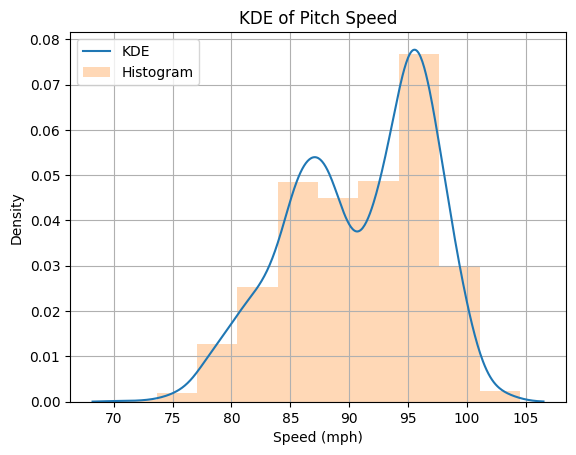

In [27]:

# Example: pitch speeds
pitch_speeds = data['release_speed'].dropna()

# Fit KDE using Silverman's rule
kde = gaussian_kde(pitch_speeds, bw_method='silverman')

# Evaluate density
x_vals = np.linspace(min(pitch_speeds) - 2, max(pitch_speeds) + 2, 500)
y_vals = kde(x_vals)

# Plot
plt.plot(x_vals, y_vals, label='KDE')
plt.hist(pitch_speeds, bins=10, density=True, alpha=0.3, label='Histogram')
plt.title('KDE of Pitch Speed')
plt.xlabel('Speed (mph)')
plt.ylabel('Density')
plt.legend()
plt.grid(True)
plt.show()


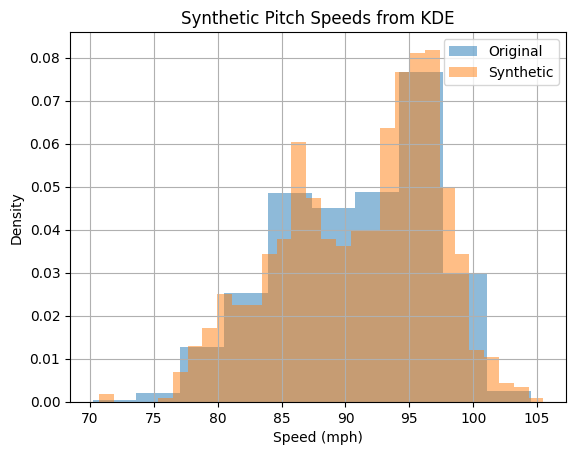

In [28]:
# Sample synthetic pitch speeds from KDE
synthetic_speeds = kde.resample(1000)[0]

# Plot synthetic vs original
plt.hist(pitch_speeds, bins=10, alpha=0.5, label='Original', density=True)
plt.hist(synthetic_speeds, bins=30, alpha=0.5, label='Synthetic', density=True)
plt.title('Synthetic Pitch Speeds from KDE')
plt.xlabel('Speed (mph)')
plt.ylabel('Density')
plt.legend()
plt.grid(True)
plt.show()


This is a large query, it may take a moment to complete


 14%|█▍        | 1/7 [00:00<00:00,  8.40it/s]/usr/local/lib/python3.12/dist-packages/pybaseball/datahelpers/postprocessing.py:59: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_datetime without passing `errors` and catch exceptions explicitly instead
  data_copy[column] = data_copy[column].apply(pd.to_datetime, errors='ignore', format=date_format)
/usr/local/lib/python3.12/dist-packages/pybaseball/datahelpers/postprocessing.py:59: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_datetime without passing `errors` and catch exceptions explicitly instead
  data_copy[column] = data_copy[column].apply(pd.to_datetime, errors='ignore', format=date_format)
/usr/local/lib/python3.12/dist-packages/pybaseball/datahelpers/postprocessing.py:59: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_datetime without passing `errors` and catch exceptions explicitly instead
  data_copy[colu

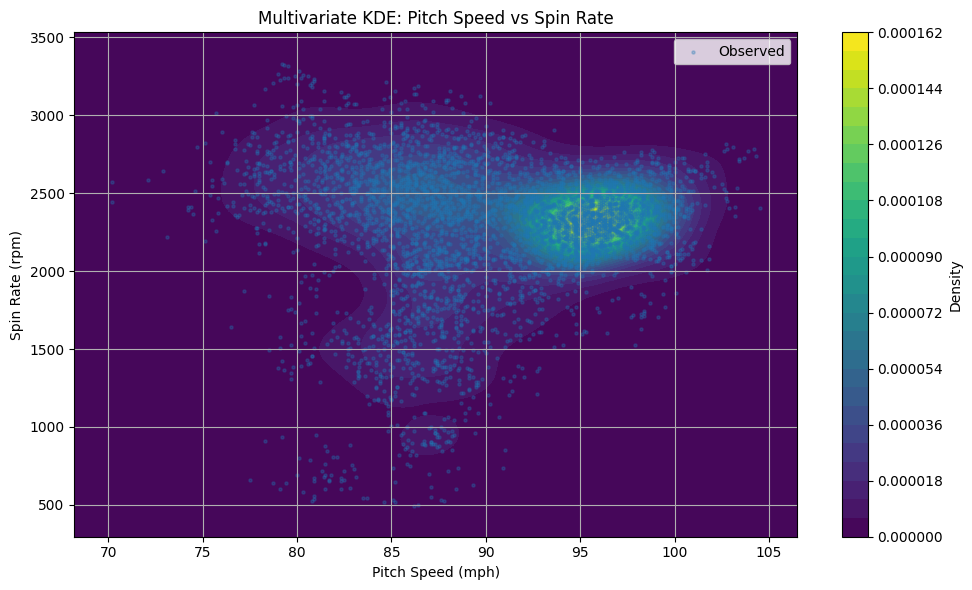

In [29]:
# Step 1: Load and clean Statcast data
df = statcast(start_dt='2025-10-01', end_dt='2025-10-07')
df = df[['release_speed', 'release_spin_rate']].dropna()
df = df.astype({'release_speed': 'float64', 'release_spin_rate': 'float64'})  # Force numeric

# Step 2: Extract data for KDE
data = df[['release_speed', 'release_spin_rate']].to_numpy().T  # shape (2, N)

# Step 3: Fit KDE
kde = gaussian_kde(data, bw_method='silverman')

# Step 4: Create grid for evaluation
x = np.linspace(data[0].min() - 2, data[0].max() + 2, 100)
y = np.linspace(data[1].min() - 200, data[1].max() + 200, 100)
X, Y = np.meshgrid(x, y)
positions = np.vstack([X.ravel(), Y.ravel()]).astype('float64')  # Ensure numeric

# Step 5: Evaluate KDE
Z = kde(positions).reshape(X.shape)

# Step 6: Plot contour
plt.figure(figsize=(10, 6))
plt.contourf(X, Y, Z, levels=30, cmap='viridis')
plt.colorbar(label='Density')
plt.scatter(data[0], data[1], s=5, alpha=0.3, label='Observed')
plt.title('Multivariate KDE: Pitch Speed vs Spin Rate')
plt.xlabel('Pitch Speed (mph)')
plt.ylabel('Spin Rate (rpm)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


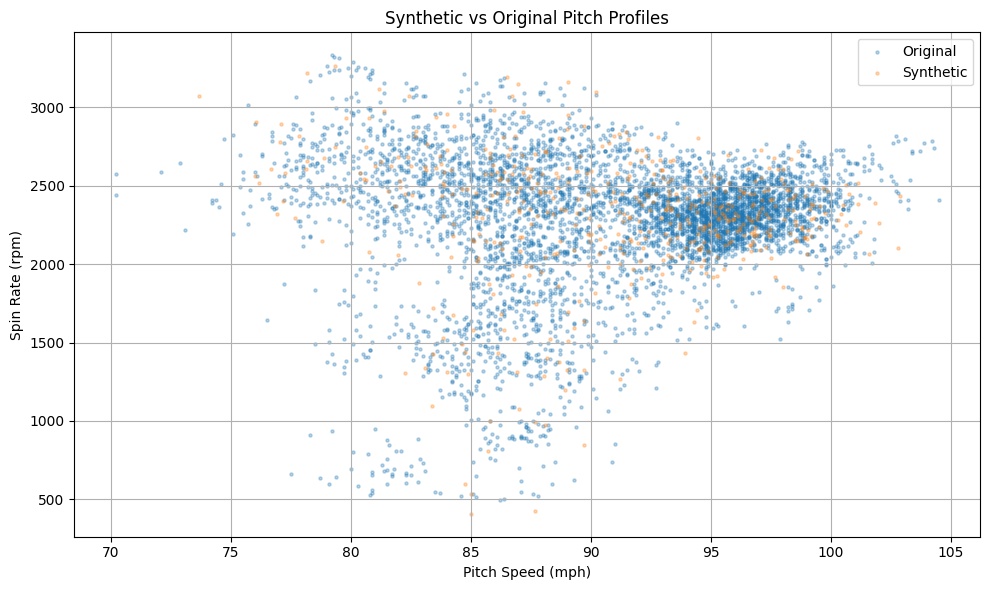

In [30]:
# Step 6: Sample synthetic pitch profiles
samples = kde.resample(500).T
synthetic_df = pd.DataFrame(samples, columns=['release_speed', 'release_spin_rate'])

# Optional: Plot synthetic vs original
plt.figure(figsize=(10, 6))
plt.scatter(df['release_speed'], df['release_spin_rate'], alpha=0.3, label='Original', s=5)
plt.scatter(synthetic_df['release_speed'], synthetic_df['release_spin_rate'], alpha=0.3, label='Synthetic', s=5)
plt.title('Synthetic vs Original Pitch Profiles')
plt.xlabel('Pitch Speed (mph)')
plt.ylabel('Spin Rate (rpm)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

Apply Clustering (e.g., KMeans)

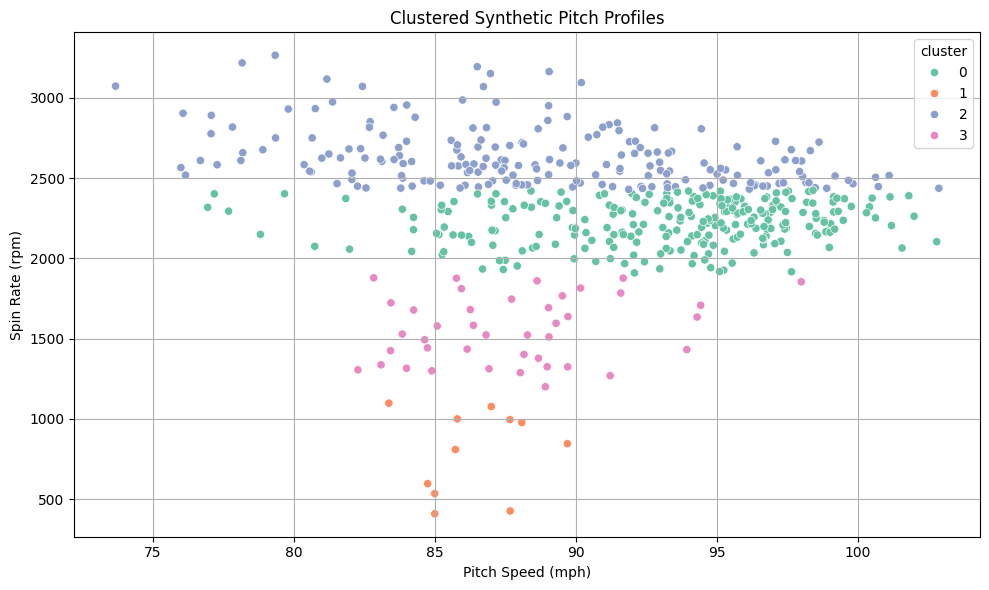

In [31]:
# Choose number of clusters (e.g., 4 for FF, SL, CH, CU)

kmeans = KMeans(n_clusters=4, random_state=42)
synthetic_df['cluster'] = kmeans.fit_predict(synthetic_df[['release_speed', 'release_spin_rate']])

# Visualize clusters
plt.figure(figsize=(10, 6))
sns.scatterplot(data=synthetic_df, x='release_speed', y='release_spin_rate', hue='cluster', palette='Set2')
plt.title('Clustered Synthetic Pitch Profiles')
plt.xlabel('Pitch Speed (mph)')
plt.ylabel('Spin Rate (rpm)')
plt.grid(True)
plt.tight_layout()
plt.show()

3. Local Constant Least Squares Regression :

  - Use case:
    - Estimate conditional expectations (e.g., expected exit velocity given launch angle).

  - Fitting:
    - Use kernel-weighted local regression to fit response curves without assuming global linearity.

  - Realism:
    - Captures local trends and heteroskedasticity in the data.

  - Bootstrap:
    - Resample residuals or fit curves to estimate uncertainty in predictions.

Fitting: Kernel-Weighted Local Regression

This is a large query, it may take a moment to complete


  0%|          | 0/7 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/pybaseball/datahelpers/postprocessing.py:59: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_datetime without passing `errors` and catch exceptions explicitly instead
  data_copy[column] = data_copy[column].apply(pd.to_datetime, errors='ignore', format=date_format)
/usr/local/lib/python3.12/dist-packages/pybaseball/datahelpers/postprocessing.py:59: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_datetime without passing `errors` and catch exceptions explicitly instead
  data_copy[column] = data_copy[column].apply(pd.to_datetime, errors='ignore', format=date_format)
/usr/local/lib/python3.12/dist-packages/pybaseball/datahelpers/postprocessing.py:59: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_datetime without passing `errors` and catch exceptions explicitly instead
  data_copy[column] = da

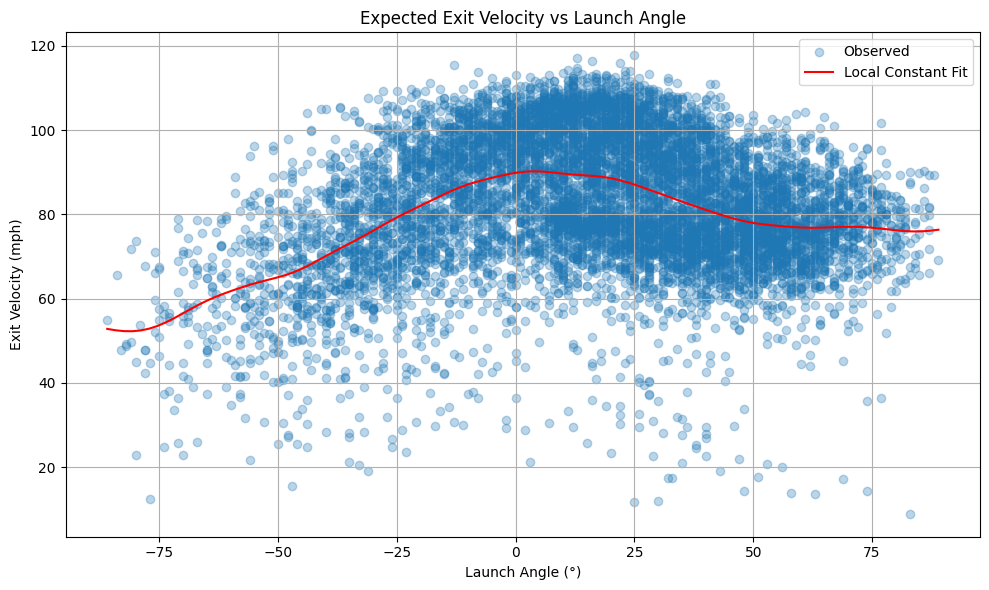

In [34]:

# Load and clean data

df = statcast(start_dt='2023-04-01', end_dt='2023-04-07')
df = df[['launch_angle', 'launch_speed']].dropna()
df = df.rename(columns={'launch_angle': 'x', 'launch_speed': 'y'})

df = df.rename(columns={'launch_angle': 'x', 'exit_velocity': 'y'})
df = df.apply(pd.to_numeric, errors='coerce').dropna()

# Define kernel-weighted local regression
def local_constant_regression(x_query, x, y, bandwidth):
    weights = np.exp(-0.5 * ((x_query - x) / bandwidth)**2)
    weights /= weights.sum()
    return np.sum(weights * y)

# Fit curve
x_vals = np.linspace(df['x'].min(), df['x'].max(), 100)
y_vals = [local_constant_regression(xq, df['x'].values, df['y'].values, bandwidth=5) for xq in x_vals]

# Plot
plt.figure(figsize=(10, 6))
plt.scatter(df['x'], df['y'], alpha=0.3, label='Observed')
plt.plot(x_vals, y_vals, color='red', label='Local Constant Fit')
plt.title('Expected Exit Velocity vs Launch Angle')
plt.xlabel('Launch Angle (°)')
plt.ylabel('Exit Velocity (mph)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


Bootstrap for Uncertainty

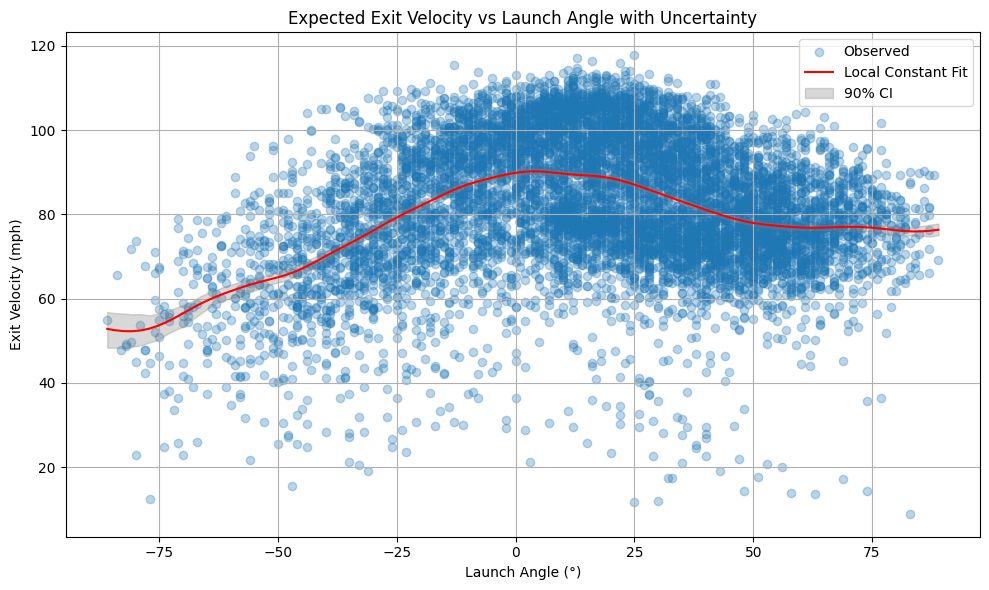

In [35]:
# Bootstrap uncertainty bands
boot_curves = []
for _ in range(100):
    sample = df.sample(frac=1, replace=True)
    y_boot = [local_constant_regression(xq, sample['x'].values, sample['y'].values, bandwidth=5) for xq in x_vals]
    boot_curves.append(y_boot)

boot_array = np.array(boot_curves)
lower = np.percentile(boot_array, 5, axis=0)
upper = np.percentile(boot_array, 95, axis=0)

# Plot with uncertainty
plt.figure(figsize=(10, 6))
plt.scatter(df['x'], df['y'], alpha=0.3, label='Observed')
plt.plot(x_vals, y_vals, color='red', label='Local Constant Fit')
plt.fill_between(x_vals, lower, upper, color='gray', alpha=0.3, label='90% CI')
plt.title('Expected Exit Velocity vs Launch Angle with Uncertainty')
plt.xlabel('Launch Angle (°)')
plt.ylabel('Exit Velocity (mph)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


Local Linear Regression with Bootstrap

4. Markov Transition Models :

  - Use case:
    - Generative modeling of sequences (e.g., pitch types, batter outcomes).

  - Fitting:
    - Estimate transition probabilities between states (e.g., pitch type → result → next pitch).

  - Realism:
    - Captures temporal dependencies and sequential structure.

  - Generative:
    - Simulate realistic sequences of events by walking the Markov chain.

In [36]:
# Step 1: Define states
states = ['0-0', '0-1', '0-2', '1-0', '1-1', '1-2', '2-0', '2-1', '2-2', '3-0', '3-1', '3-2', 'K', 'BB', 'H']

# Step 2: Define transition matrix (simplified example)
transition_matrix = {
    '0-0': {'1-0': 0.3, '0-1': 0.5, 'H': 0.2},
    '1-0': {'2-0': 0.4, '1-1': 0.4, 'H': 0.2},
    '0-1': {'0-2': 0.5, '1-1': 0.3, 'H': 0.2},
    '1-1': {'2-1': 0.3, '1-2': 0.4, 'H': 0.3},
    '2-0': {'3-0': 0.5, '2-1': 0.3, 'H': 0.2},
    '0-2': {'K': 0.6, '1-2': 0.3, 'H': 0.1},
    '1-2': {'K': 0.5, '2-2': 0.3, 'H': 0.2},
    '2-1': {'3-1': 0.4, '2-2': 0.4, 'H': 0.2},
    '2-2': {'K': 0.4, 'BB': 0.3, 'H': 0.3},
    '3-0': {'BB': 0.6, '3-1': 0.3, 'H': 0.1},
    '3-1': {'BB': 0.5, '3-2': 0.3, 'H': 0.2},
    '3-2': {'K': 0.3, 'BB': 0.3, 'H': 0.4}
}

# Step 3: Simulate sequence
def simulate_sequence(start='0-0'):
    sequence = [start]
    current = start
    while current not in ['K', 'BB', 'H']:
        next_states = list(transition_matrix[current].keys())
        probs = list(transition_matrix[current].values())
        current = random.choices(next_states, probs)[0]
        sequence.append(current)
    return sequence

# Example
for _ in range(5):
    print(simulate_sequence())


['0-0', '0-1', '1-1', '1-2', 'H']
['0-0', '0-1', 'H']
['0-0', '1-0', '1-1', '1-2', 'K']
['0-0', '0-1', '1-1', '1-2', '2-2', 'H']
['0-0', '0-1', '1-1', '2-1', 'H']


In [54]:
df = statcast(start_dt='2025-10-01', end_dt='2025-10-31')


This is a large query, it may take a moment to complete


  3%|▎         | 1/31 [00:00<00:03,  7.53it/s]/usr/local/lib/python3.12/dist-packages/pybaseball/datahelpers/postprocessing.py:59: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_datetime without passing `errors` and catch exceptions explicitly instead
  data_copy[column] = data_copy[column].apply(pd.to_datetime, errors='ignore', format=date_format)
  6%|▋         | 2/31 [00:00<00:04,  6.25it/s]/usr/local/lib/python3.12/dist-packages/pybaseball/datahelpers/postprocessing.py:59: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_datetime without passing `errors` and catch exceptions explicitly instead
  data_copy[column] = data_copy[column].apply(pd.to_datetime, errors='ignore', format=date_format)
/usr/local/lib/python3.12/dist-packages/pybaseball/datahelpers/postprocessing.py:59: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_datetime without passing `errors` and catch

In [44]:
print(df.columns.tolist())

['pitch_type', 'game_date', 'release_speed', 'release_pos_x', 'release_pos_z', 'player_name', 'batter', 'pitcher', 'events', 'description', 'spin_dir', 'spin_rate_deprecated', 'break_angle_deprecated', 'break_length_deprecated', 'zone', 'des', 'game_type', 'stand', 'p_throws', 'home_team', 'away_team', 'type', 'hit_location', 'bb_type', 'balls', 'strikes', 'game_year', 'pfx_x', 'pfx_z', 'plate_x', 'plate_z', 'on_3b', 'on_2b', 'on_1b', 'outs_when_up', 'inning', 'inning_topbot', 'hc_x', 'hc_y', 'tfs_deprecated', 'tfs_zulu_deprecated', 'umpire', 'sv_id', 'vx0', 'vy0', 'vz0', 'ax', 'ay', 'az', 'sz_top', 'sz_bot', 'hit_distance_sc', 'launch_speed', 'launch_angle', 'effective_speed', 'release_spin_rate', 'release_extension', 'game_pk', 'fielder_2', 'fielder_3', 'fielder_4', 'fielder_5', 'fielder_6', 'fielder_7', 'fielder_8', 'fielder_9', 'release_pos_y', 'estimated_ba_using_speedangle', 'estimated_woba_using_speedangle', 'woba_value', 'woba_denom', 'babip_value', 'iso_value', 'launch_speed_a

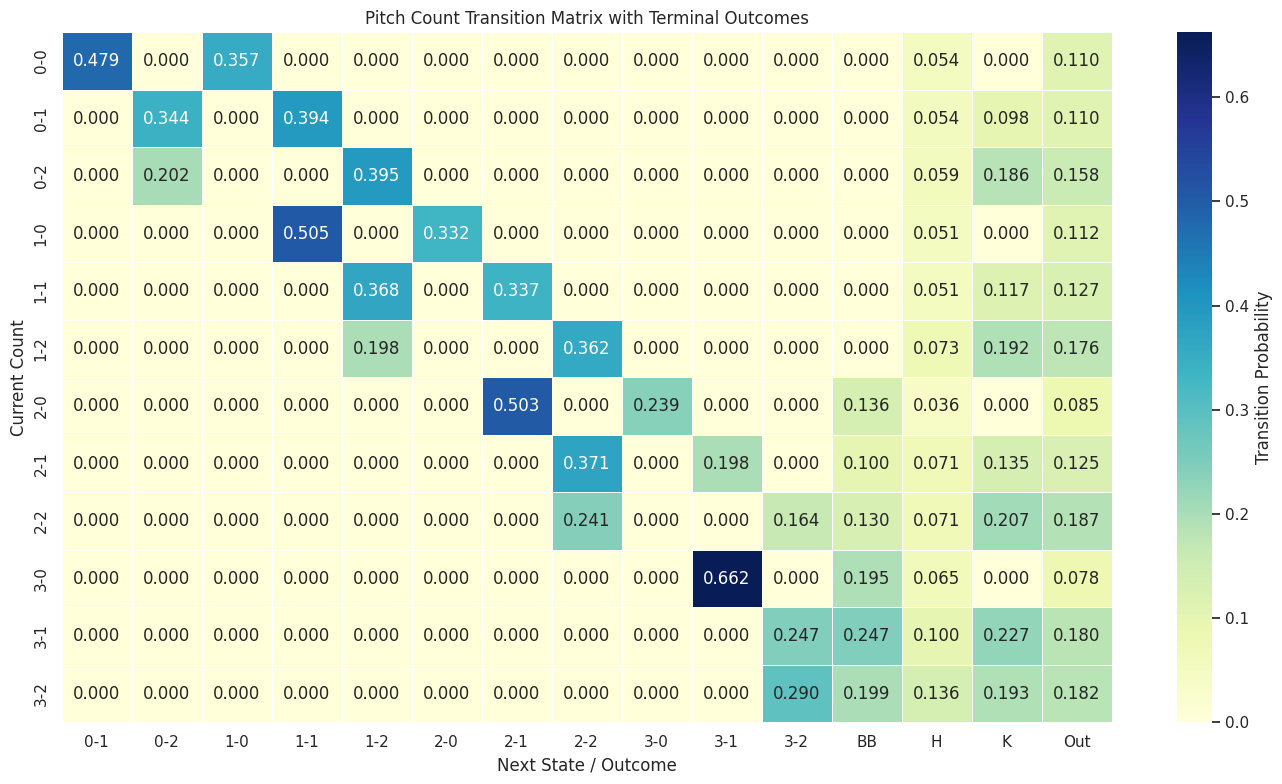

In [45]:
# Step 1: Load pitch-by-pitch data
cols = ['game_pk', 'at_bat_number', 'pitch_number', 'balls', 'strikes', 'events', 'description']

# Step 2: Filter out terminal counts
df = df[(df['balls'] <= 3) & (df['strikes'] <= 2)]

# Step 3: Create count label
df['count'] = df['balls'].astype(str) + '-' + df['strikes'].astype(str)

# Step 4: Create plate appearance ID and sort
df['pa_id'] = df['game_pk'].astype(str) + '-' + df['at_bat_number'].astype(str)
df = df.sort_values(['pa_id', 'pitch_number'])

# Step 5: Define terminal outcomes
def classify_terminal(row):
    if row['events'] in ['strikeout', 'strikeout_double_play']:
        return 'K'
    elif row['events'] in ['walk', 'intent_walk']:
        return 'BB'
    elif row['events'] in ['single', 'double', 'triple', 'home_run']:
        return 'H'
    elif row['events'] in ['field_out', 'force_out', 'double_play', 'grounded_into_double_play']:
        return 'Out'
    return None

df['outcome'] = df.apply(classify_terminal, axis=1)

# Step 6: Compute next count or terminal outcome
df['next_state'] = df.groupby('pa_id')['count'].shift(-1)
df['next_outcome'] = df.groupby('pa_id')['outcome'].shift(-1)

# Step 7: Combine next count and outcome
df['next'] = df['next_state']
mask = df['next_outcome'].notna()
df.loc[mask, 'next'] = df.loc[mask, 'next_outcome'].values

# Step 8: Drop last pitch of each PA (no next state)
df['is_last'] = df.groupby('pa_id')['pitch_number'].transform('max') == df['pitch_number']
df = df[~df['is_last']]

# Step 9: Filter valid transitions
valid_counts = ['0-0','0-1','0-2','1-0','1-1','1-2','2-0','2-1','2-2','3-0','3-1','3-2']
valid_next = valid_counts + ['K', 'BB', 'H', 'Out']
df = df[df['count'].isin(valid_counts) & df['next'].isin(valid_next)]

# Step 10: Build transition matrix
transitions = df.groupby(['count', 'next']).size().unstack(fill_value=0)
transition_matrix = transitions.div(transitions.sum(axis=1), axis=0)


index = ['0-0','0-1','0-2','1-0','1-1','1-2','2-0','2-1','2-2','3-0','3-1','3-2']
df = pd.DataFrame(transition_matrix, index=index)

# Create heatmap
plt.figure(figsize=(14, 8))
sns.set(style="whitegrid")
sns.heatmap(df, annot=True, fmt=".3f", cmap="YlGnBu", linewidths=0.5, cbar_kws={'label': 'Transition Probability'})
plt.title("Pitch Count Transition Matrix with Terminal Outcomes")
plt.xlabel("Next State / Outcome")
plt.ylabel("Current Count")
plt.tight_layout()
plt.show()

In [ ]:
transition_matrix

/tmp/ipython-input-837371022.py:52: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


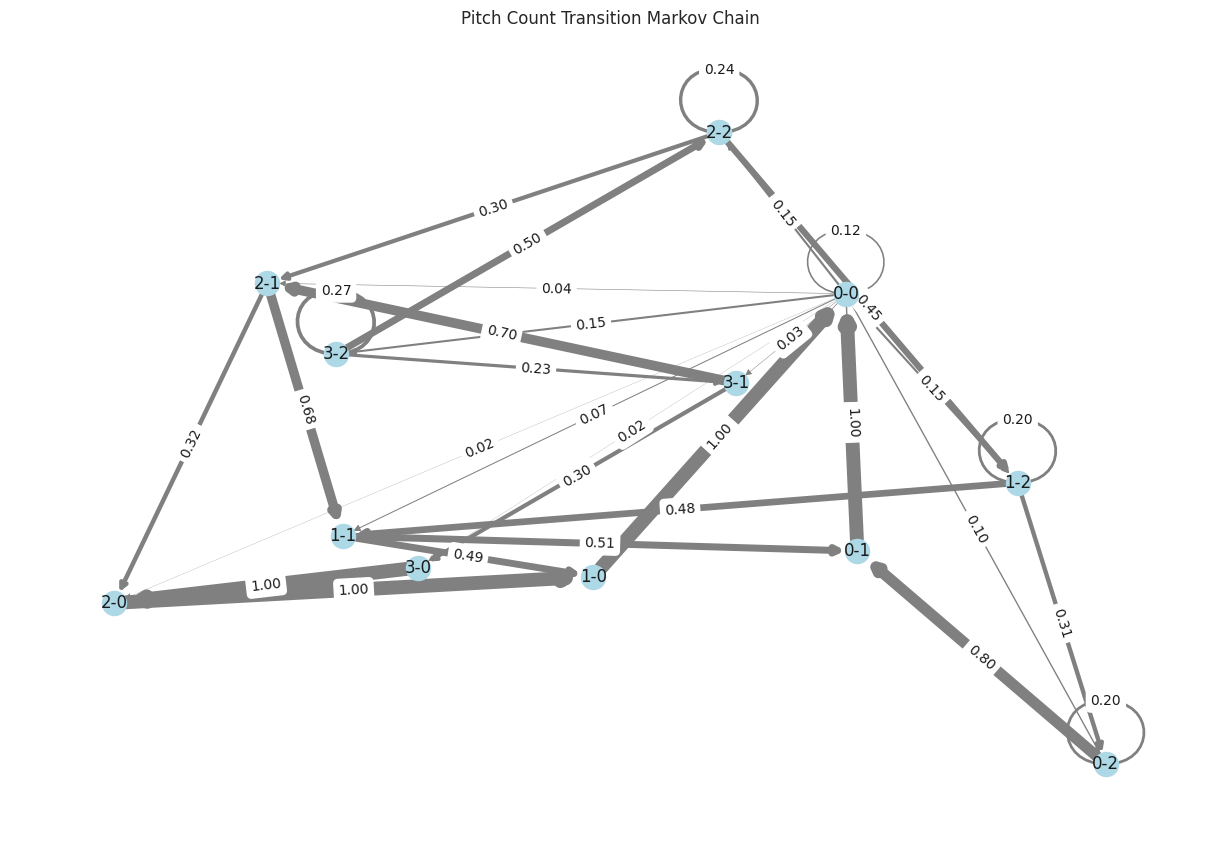

In [49]:

# Step 1: Load pitch-by-pitch data
df = df[['balls', 'strikes']].dropna()
df = df[(df['balls'] <= 3) & (df['strikes'] <= 2)]  # exclude terminal counts

# Step 2: Create count state labels
df['count'] = df['balls'].astype(str) + '-' + df['strikes'].astype(str)
df['next_count'] = df['count'].shift(-1)

# Step 3: Filter valid transitions
df = df[df['next_count'].notna()]
valid_counts = df['count'].isin([
    '0-0','0-1','0-2','1-0','1-1','1-2','2-0','2-1','2-2','3-0','3-1','3-2'
])
df = df[valid_counts]

# Step 4: Build transition matrix
transitions = df.groupby(['count', 'next_count']).size().unstack(fill_value=0)
transition_probs = transitions.div(transitions.sum(axis=1), axis=0)

# Step 5: Simulate sequences
def simulate_sequence(matrix, start='0-0', max_steps=10):
    sequence = [start]
    current = start
    for _ in range(max_steps):
        if current not in matrix.index:
            break
        next_states = matrix.columns
        probs = matrix.loc[current].values
        if probs.sum() == 0:
            break
        current = np.random.choice(next_states, p=probs)
        sequence.append(current)
    return sequence

sequences = [simulate_sequence(transition_probs) for _ in range(1000)]

# Step 6: Visualize as directed graph
G = nx.DiGraph()
for from_state in transition_probs.index:
    for to_state in transition_probs.columns:
        prob = transition_probs.loc[from_state, to_state]
        if prob > 0:
            G.add_edge(from_state, to_state, weight=prob)

plt.figure(figsize=(12, 8))
pos = nx.spring_layout(G, seed=42)
edges = G.edges(data=True)
weights = [d['weight'] * 10 for (_, _, d) in edges]
nx.draw(G, pos, with_labels=True, node_color='lightblue', edge_color='gray', width=weights, arrows=True)
nx.draw_networkx_edge_labels(G, pos, edge_labels={(u, v): f"{d['weight']:.2f}" for u, v, d in edges})
plt.title("Pitch Count Transition Markov Chain")
plt.tight_layout()
plt.show()

Pitch Count Sequence Simulation Code

In [50]:

transition_dict = transition_matrix.dropna(how='all').to_dict(orient='index')

# Step 2: Convert to nested dictionary
transition_dict = transition_matrix.to_dict(orient='index')

# Step 3: Simulate pitch count sequence
def simulate_sequence(start='0-0'):
    sequence = [start]
    current = start
    terminal_states = ['K', 'BB', 'H', 'Out']
    while current not in terminal_states:
        if current not in transition_dict:
            break  # safety check
        next_states = list(transition_dict[current].keys())
        probs = list(transition_dict[current].values())
        current = random.choices(next_states, weights=probs, k=1)[0]
        sequence.append(current)
    return sequence

# Step 4: Run multiple simulations
for i in range(5):
    seq = simulate_sequence()
    print(f"Plate Appearance {i+1}: {' → '.join(seq)}")

Plate Appearance 1: 0-0 → 0-1 → K
Plate Appearance 2: 0-0 → 1-0 → 1-1 → Out
Plate Appearance 3: 0-0 → 0-1 → 1-1 → 1-2 → 2-2 → 3-2 → 3-2 → Out
Plate Appearance 4: 0-0 → 0-1 → 1-1 → 1-2 → Out
Plate Appearance 5: 0-0 → Out


✅ Outcome Frequencies (1000 Simulated Plate Appearances):
BB     0.083
H      0.186
K      0.283
Out    0.448
Name: proportion, dtype: float64

📊 Pitch Count Stats per Plate Appearance:
count    1000.00
mean        4.32
std         1.72
min         2.00
25%         3.00
50%         4.00
75%         6.00
max        11.00
dtype: float64


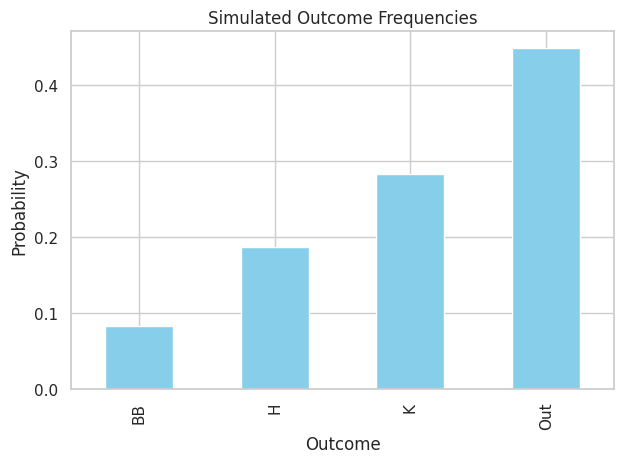

In [51]:
# Step 3: Simulate many plate appearances
def simulate_many(n=1000):
    outcomes = []
    pitch_counts = []
    for _ in range(n):
        seq = simulate_sequence()
        outcomes.append(seq[-1])
        pitch_counts.append(len(seq))
    return outcomes, pitch_counts

# Step 4: Run simulation
n_simulations = 1000
outcomes, pitch_counts = simulate_many(n_simulations)

# Step 5: Summarize results
outcome_freq = pd.Series(outcomes).value_counts(normalize=True).sort_index()
pitch_stats = pd.Series(pitch_counts).describe()

print("✅ Outcome Frequencies (1000 Simulated Plate Appearances):")
print(outcome_freq.round(3))
print("\n📊 Pitch Count Stats per Plate Appearance:")
print(pitch_stats.round(2))

# Step 6: Optional visualization
outcome_freq.plot(kind='bar', color='skyblue', title='Simulated Outcome Frequencies')
plt.ylabel('Probability')
plt.xlabel('Outcome')
plt.tight_layout()
plt.show()

Full Inning Simulation Code

In [52]:
terminal_states = ['K', 'BB', 'H', 'Out']

# Simulate a single plate appearance
def simulate_sequence(start='0-0'):
    sequence = [start]
    current = start
    while current not in terminal_states:
        if current not in transition_dict:
            break
        next_states = list(transition_dict[current].keys())
        probs = list(transition_dict[current].values())
        current = random.choices(next_states, weights=probs, k=1)[0]
        sequence.append(current)
    return current, len(sequence)

# Simulate one half-inning
def simulate_half_inning():
    outs = 0
    runs = 0
    bases = [False, False, False]  # [1st, 2nd, 3rd]
    pitch_total = 0

    def advance_runners(outcome):
        nonlocal runs, bases
        if outcome == 'H':
            if bases[2]: runs += 1
            if bases[1]: bases[2] = True
            if bases[0]: bases[1] = True
            bases[0] = True
        elif outcome == 'BB':
            if bases[0] and bases[1] and bases[2]: runs += 1
            elif bases[0] and bases[1]: bases[2] = True
            elif bases[0]: bases[1] = True
            bases[0] = True

    while outs < 3:
        outcome, pitch_count = simulate_sequence()
        pitch_total += pitch_count
        if outcome in ['Out', 'K']:
            outs += 1
        else:
            advance_runners(outcome)

    return runs, pitch_total

# Simulate full 9-inning game
def simulate_game():
    home_runs = 0
    away_runs = 0
    home_pitches = 0
    away_pitches = 0

    print("🏟️ Simulating 9-Inning Game")
    for inning in range(1, 10):
        away_r, away_p = simulate_half_inning()
        home_r, home_p = simulate_half_inning()
        away_runs += away_r
        home_runs += home_r
        away_pitches += away_p
        home_pitches += home_p
        print(f"Inning {inning}: Away {away_r} runs ({away_p} pitches), Home {home_r} runs ({home_p} pitches)")

    print(f"\n🏁 Final Score: Away {away_runs} – Home {home_runs}")
    print(f"🧮 Total Pitches: Away {away_pitches}, Home {home_pitches}")

simulate_game()

🏟️ Simulating 9-Inning Game
Inning 1: Away 0 runs (29 pitches), Home 0 runs (25 pitches)
Inning 2: Away 0 runs (16 pitches), Home 0 runs (18 pitches)
Inning 3: Away 0 runs (18 pitches), Home 0 runs (12 pitches)
Inning 4: Away 0 runs (16 pitches), Home 0 runs (21 pitches)
Inning 5: Away 0 runs (12 pitches), Home 0 runs (27 pitches)
Inning 6: Away 0 runs (25 pitches), Home 0 runs (12 pitches)
Inning 7: Away 0 runs (19 pitches), Home 0 runs (13 pitches)
Inning 8: Away 0 runs (24 pitches), Home 0 runs (26 pitches)
Inning 9: Away 0 runs (13 pitches), Home 0 runs (9 pitches)

🏁 Final Score: Away 0 – Home 0
🧮 Total Pitches: Away 172, Home 163


Batter Vs Pitcher

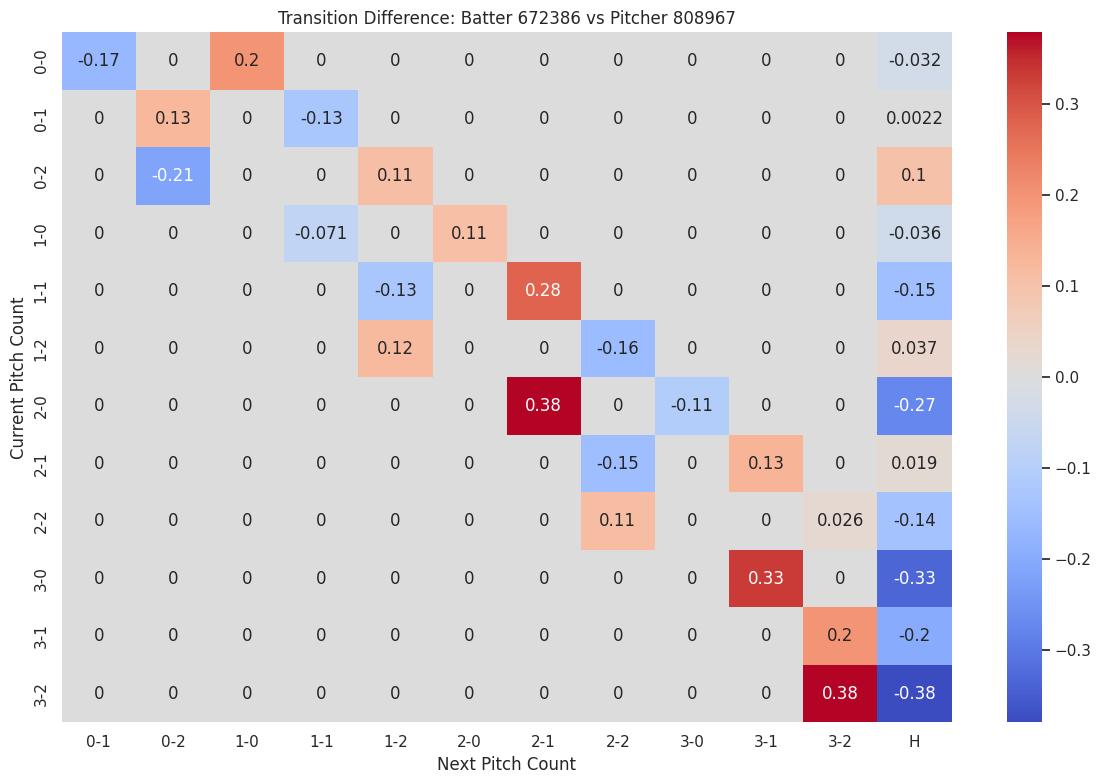

In [55]:
df = df.sort_values(['game_date', 'at_bat_number', 'pitch_number'])

# Step 2: Create pitch count labels
df['pitch_count'] = df['balls'].astype(str) + '-' + df['strikes'].astype(str)

# Step 3: Create next pitch count within same at-bat and matchup
same_atbat = (
    (df['at_bat_number'] == df['at_bat_number'].shift(-1)) &
    (df['batter'] == df['batter'].shift(-1)) &
    (df['pitcher'] == df['pitcher'].shift(-1))
)
df['next_pitch_count'] = df['pitch_count'].shift(-1).where(same_atbat)

# Step 4: Replace terminal outcomes
terminal_map = {'strikeout': 'K', 'walk': 'BB', 'hit_into_play': 'H'}
df['next_pitch_count'] = df['next_pitch_count'].mask(
    df['description'].isin(terminal_map.keys()),
    df['description'].map(terminal_map)
)

# Step 5: Filter valid transitions
transitions_df = df.dropna(subset=['pitch_count', 'next_pitch_count'])

# Step 6: Remove rows where pitch_count is a terminal outcome
terminal_states = ['K', 'BB', 'H', 'Out']
transitions_df = transitions_df[~transitions_df['pitch_count'].isin(terminal_states)]

# Step 7: Remove back transitions (e.g., 1-0 → 0-0)
def is_forward_transition(start, end):
    try:
        if end in terminal_states:
            return True
        b1, s1 = map(int, start.split('-'))
        b2, s2 = map(int, end.split('-'))
        return (b2 >= b1 and s2 >= s1)
    except:
        return False

transitions_df = transitions_df[
    transitions_df.apply(lambda row: is_forward_transition(row['pitch_count'], row['next_pitch_count']), axis=1)
]

# Step 8: Build transition matrix function
def build_transition_matrix(sub_df):
    transitions = sub_df.groupby(['pitch_count', 'next_pitch_count']).size().unstack(fill_value=0)
    matrix = transitions.div(transitions.sum(axis=1), axis=0)
    return matrix.fillna(0)

# Step 9: Filter players with enough data
valid_batters = transitions_df['batter'].value_counts()
valid_pitchers = transitions_df['pitcher'].value_counts()

batter_matrices = {
    b: build_transition_matrix(transitions_df[transitions_df['batter'] == b])
    for b in valid_batters[valid_batters > 100].index
}

pitcher_matrices = {
    p: build_transition_matrix(transitions_df[transitions_df['pitcher'] == p])
    for p in valid_pitchers[valid_pitchers > 100].index
}

# Step 10: Safely select batter and pitcher
if not batter_matrices:
    print("⚠️ No batters with enough transitions. Try lowering the threshold or inspecting transition counts.")
elif not pitcher_matrices:
    print("⚠️ No pitchers with enough transitions. Try lowering the threshold or inspecting transition counts.")
else:
    batter_id = list(batter_matrices.keys())[0]
    pitcher_id = list(pitcher_matrices.keys())[0]

    b_matrix = batter_matrices[batter_id]
    p_matrix = pitcher_matrices[pitcher_id]

# Step 11: Align and compare
all_rows = sorted(set(b_matrix.index).union(p_matrix.index))
all_cols = sorted(set(b_matrix.columns).union(p_matrix.columns))

b_matrix = b_matrix.reindex(index=all_rows, columns=all_cols, fill_value=0)
p_matrix = p_matrix.reindex(index=all_rows, columns=all_cols, fill_value=0)

comparison = b_matrix - p_matrix

# Step 12: Visualize the difference
plt.figure(figsize=(12, 8))
sns.heatmap(comparison, annot=True, cmap='coolwarm', center=0)
plt.title(f"Transition Difference: Batter {batter_id} vs Pitcher {pitcher_id}")
plt.xlabel("Next Pitch Count")
plt.ylabel("Current Pitch Count")
plt.tight_layout()
plt.show()